In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# APPLICATION RECORD

In [48]:
app = pd.read_csv("application_record.csv")


In [49]:
app.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [50]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [51]:
app.columns.tolist()

['ID',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS']

In [52]:
app.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [53]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


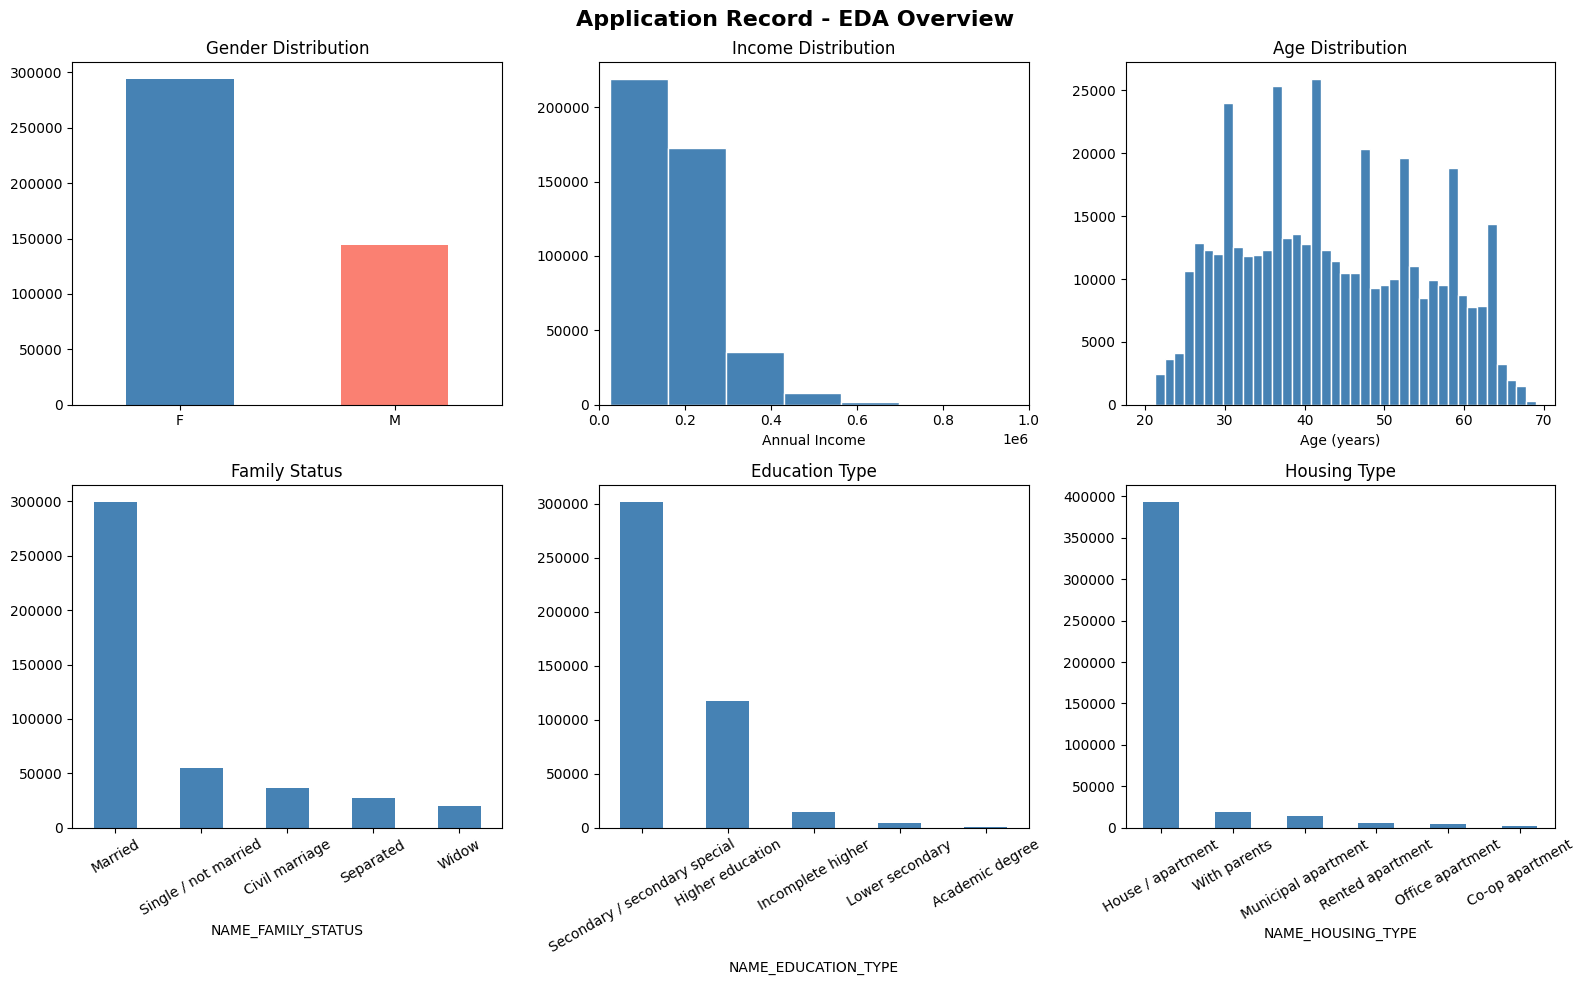

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Application Record - EDA Overview", fontsize=16, fontweight='bold')

# 1. Gender distribution
app['CODE_GENDER'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue', 'salmon'])
axes[0,0].set_title("Gender Distribution")
axes[0,0].set_xlabel("")
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Income distribution
axes[0,1].hist(app['AMT_INCOME_TOTAL'], bins=50, color='steelblue', edgecolor='white')
axes[0,1].set_title("Income Distribution")
axes[0,1].set_xlabel("Annual Income")
axes[0,1].set_xlim(0, 1_000_000)  # Cap outliers for visibility

# 3. Age distribution (convert DAYS_BIRTH to years)
app['AGE'] = (-app['DAYS_BIRTH'] / 365).astype(int)
axes[0,2].hist(app['AGE'], bins=40, color='steelblue', edgecolor='white')
axes[0,2].set_title("Age Distribution")
axes[0,2].set_xlabel("Age (years)")

# 4. Family status
app['NAME_FAMILY_STATUS'].value_counts().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title("Family Status")
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Education type
app['NAME_EDUCATION_TYPE'].value_counts().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title("Education Type")
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Housing type
app['NAME_HOUSING_TYPE'].value_counts().plot(kind='bar', ax=axes[1,2], color='steelblue')
axes[1,2].set_title("Housing Type")
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [55]:
# Income deep dive
print("Income percentiles:")
print(app['AMT_INCOME_TOTAL'].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]))

print(f"\nPeople earning over 500k: {(app['AMT_INCOME_TOTAL'] > 500_000).sum()}")
print(f"People earning over 1M: {(app['AMT_INCOME_TOTAL'] > 1_000_000).sum()}")

Income percentiles:
0.25     121500.0
0.50     160780.5
0.75     225000.0
0.90     315000.0
0.95     360000.0
0.99     540000.0
1.00    6750000.0
Name: AMT_INCOME_TOTAL, dtype: float64

People earning over 500k: 5398
People earning over 1M: 430


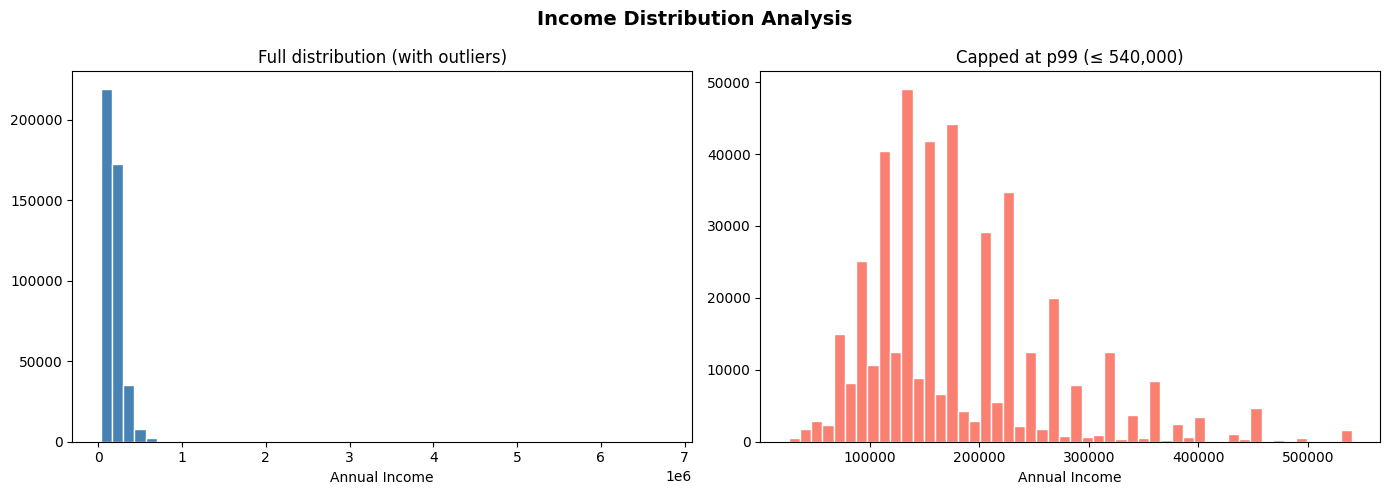

In [56]:
# Income distribution without outliers (capped at 99th percentile)
income_cap = app['AMT_INCOME_TOTAL'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Income Distribution Analysis", fontsize=14, fontweight='bold')

# Full distribution
axes[0].hist(app['AMT_INCOME_TOTAL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Full distribution (with outliers)")
axes[0].set_xlabel("Annual Income")

# Capped at p99
axes[1].hist(app[app['AMT_INCOME_TOTAL'] <= income_cap]['AMT_INCOME_TOTAL'], 
             bins=50, color='salmon', edgecolor='white')
axes[1].set_title(f"Capped at p99 (≤ {income_cap:,.0f})")
axes[1].set_xlabel("Annual Income")

plt.tight_layout()
plt.show()

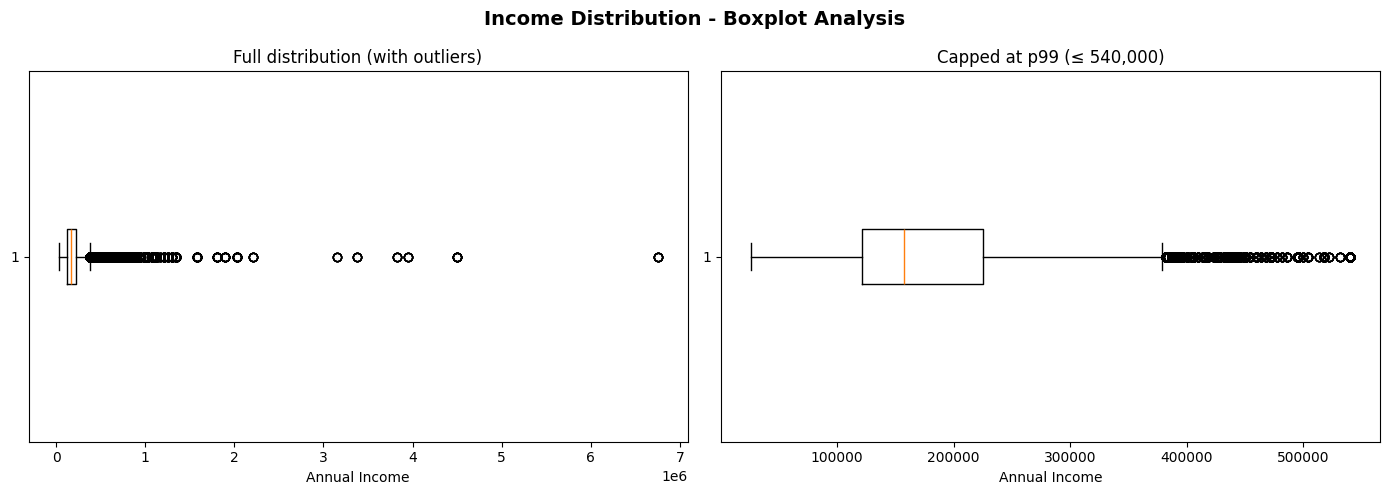

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Income Distribution - Boxplot Analysis", fontsize=14, fontweight='bold')

# Full distribution
axes[0].boxplot(app['AMT_INCOME_TOTAL'], vert=False)
axes[0].set_title("Full distribution (with outliers)")
axes[0].set_xlabel("Annual Income")

# Capped at p99
income_cap = app['AMT_INCOME_TOTAL'].quantile(0.99)
axes[1].boxplot(app[app['AMT_INCOME_TOTAL'] <= income_cap]['AMT_INCOME_TOTAL'], vert=False)
axes[1].set_title(f"Capped at p99 (≤ {income_cap:,.0f})")
axes[1].set_xlabel("Annual Income")

plt.tight_layout()
plt.show()

In [58]:
# Investigate DAYS_EMPLOYED
print(f"Max value: {app['DAYS_EMPLOYED'].max()}")
print(f"How many have 365243: {(app['DAYS_EMPLOYED'] == 365243).sum()}")
print(f"Percentage: {(app['DAYS_EMPLOYED'] == 365243).mean() * 100:.2f}%")

print(f"\nWithout anomaly - stats:")
print(app[app['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED'].describe())

Max value: 365243
How many have 365243: 75329
Percentage: 17.18%

Without anomaly - stats:
count    363228.000000
mean      -2623.052700
std        2399.514253
min      -17531.000000
25%       -3512.000000
50%       -1924.000000
75%        -915.000000
max         -12.000000
Name: DAYS_EMPLOYED, dtype: float64


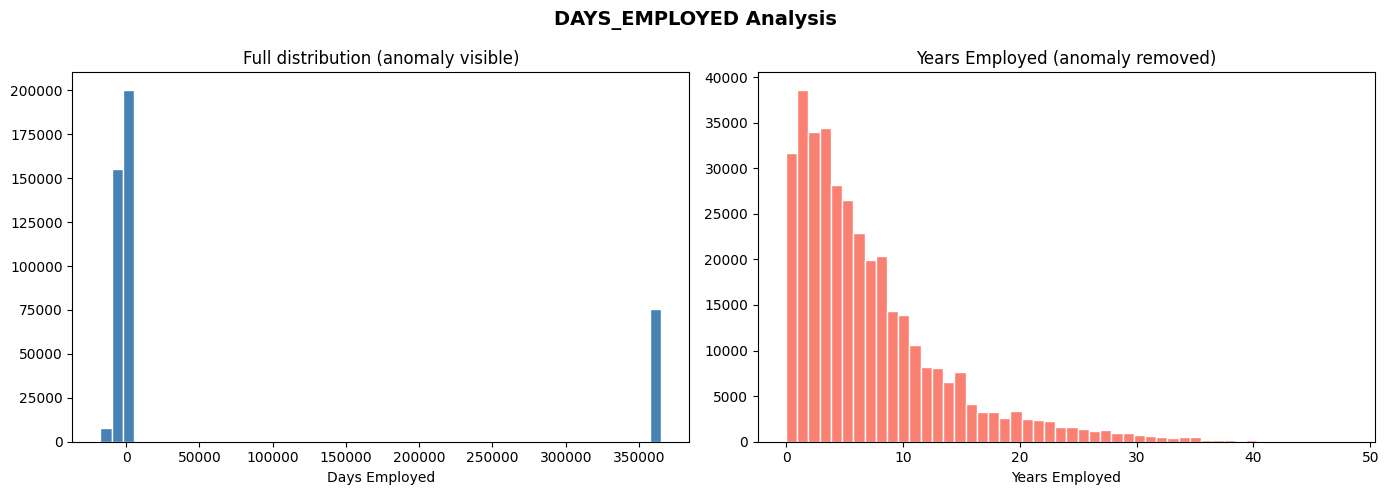

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DAYS_EMPLOYED Analysis", fontsize=14, fontweight='bold')

# Full distribution - spot the anomaly
axes[0].hist(app['DAYS_EMPLOYED'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Full distribution (anomaly visible)")
axes[0].set_xlabel("Days Employed")

# Without anomaly - converted to years
clean = app[app['DAYS_EMPLOYED'] != 365243].copy()
clean['YEARS_EMPLOYED'] = (-clean['DAYS_EMPLOYED'] / 365).round(1)
axes[1].hist(clean['YEARS_EMPLOYED'], bins=50, color='salmon', edgecolor='white')
axes[1].set_title("Years Employed (anomaly removed)")
axes[1].set_xlabel("Years Employed")

plt.tight_layout()
plt.show()

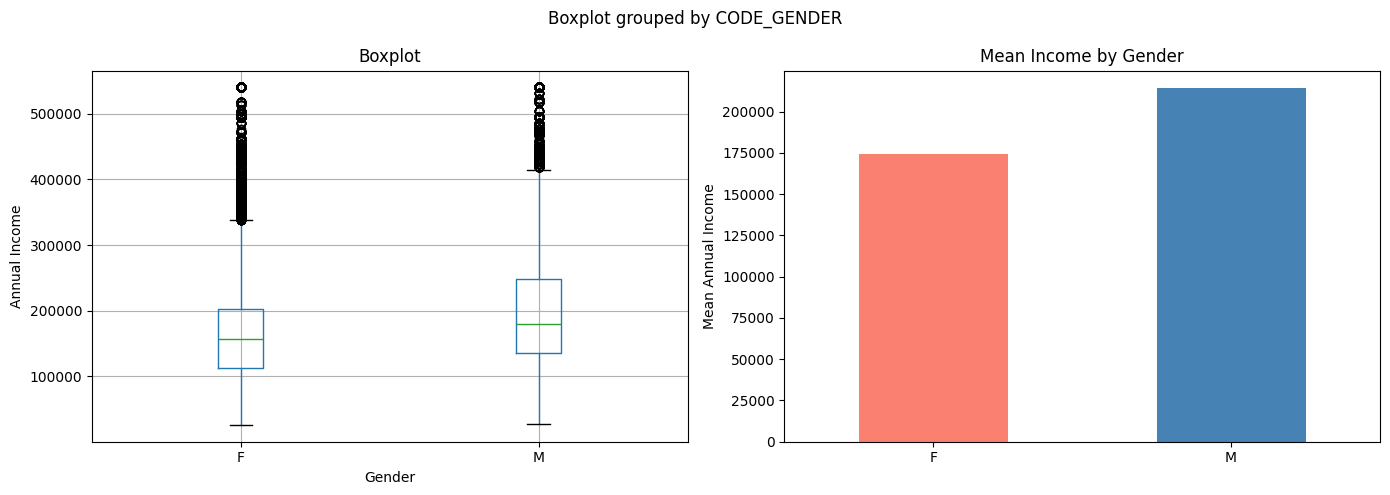

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Income by Gender", fontsize=14, fontweight='bold')

# Boxplot income by gender (capped at p99)
income_cap = app['AMT_INCOME_TOTAL'].quantile(0.99)
app_capped = app[app['AMT_INCOME_TOTAL'] <= income_cap]

app_capped.boxplot(column='AMT_INCOME_TOTAL', by='CODE_GENDER', ax=axes[0])
axes[0].set_title("Boxplot")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Annual Income")

# Mean income by gender
app.groupby('CODE_GENDER')['AMT_INCOME_TOTAL'].mean().plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'])
axes[1].set_title("Mean Income by Gender")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean Annual Income")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [61]:
# Exact stats by gender
print(app.groupby('CODE_GENDER')['AMT_INCOME_TOTAL'].agg(['mean', 'median', 'std']).round(0))

# Gender count reminder
print(f"\nGender counts:")
print(app['CODE_GENDER'].value_counts())

                 mean    median       std
CODE_GENDER                              
F            174523.0  157500.0   95701.0
M            214087.0  184500.0  130831.0

Gender counts:
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64


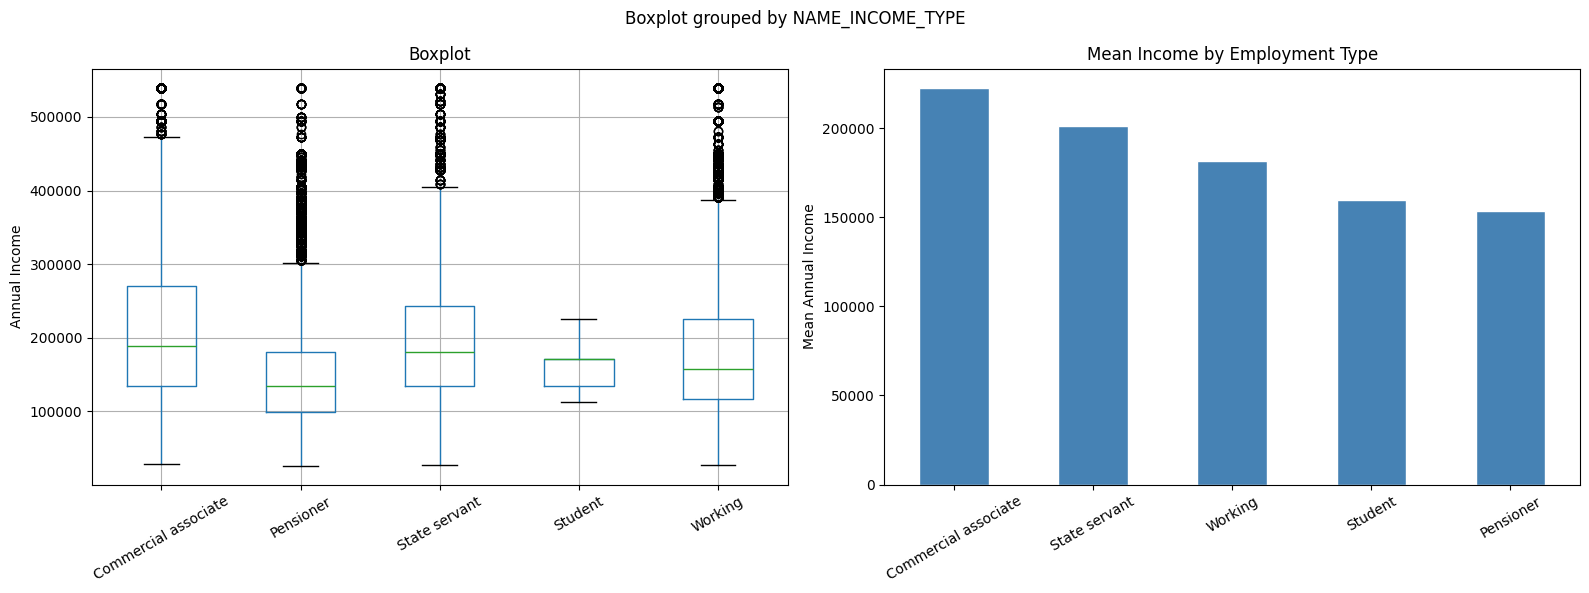

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Income by Employment Type", fontsize=14, fontweight='bold')

# Boxplot by income type (capped at p99)
income_cap = app['AMT_INCOME_TOTAL'].quantile(0.99)
app_capped = app[app['AMT_INCOME_TOTAL'] <= income_cap]

app_capped.boxplot(column='AMT_INCOME_TOTAL', by='NAME_INCOME_TYPE', ax=axes[0])
axes[0].set_title("Boxplot")
axes[0].set_xlabel("")
axes[0].set_ylabel("Annual Income")
axes[0].tick_params(axis='x', rotation=30)

# Mean income by employment type
app.groupby('NAME_INCOME_TYPE')['AMT_INCOME_TOTAL'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title("Mean Income by Employment Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean Annual Income")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [63]:
# Count and stats by employment type
print(app.groupby('NAME_INCOME_TYPE')['AMT_INCOME_TOTAL'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False).round(0))

                       count      mean    median
NAME_INCOME_TYPE                                
Working               226104  181256.0  157500.0
Commercial associate  100757  222224.0  202500.0
Pensioner              75493  153570.0  135000.0
State servant          36186  200921.0  180000.0
Student                   17  159618.0  171000.0


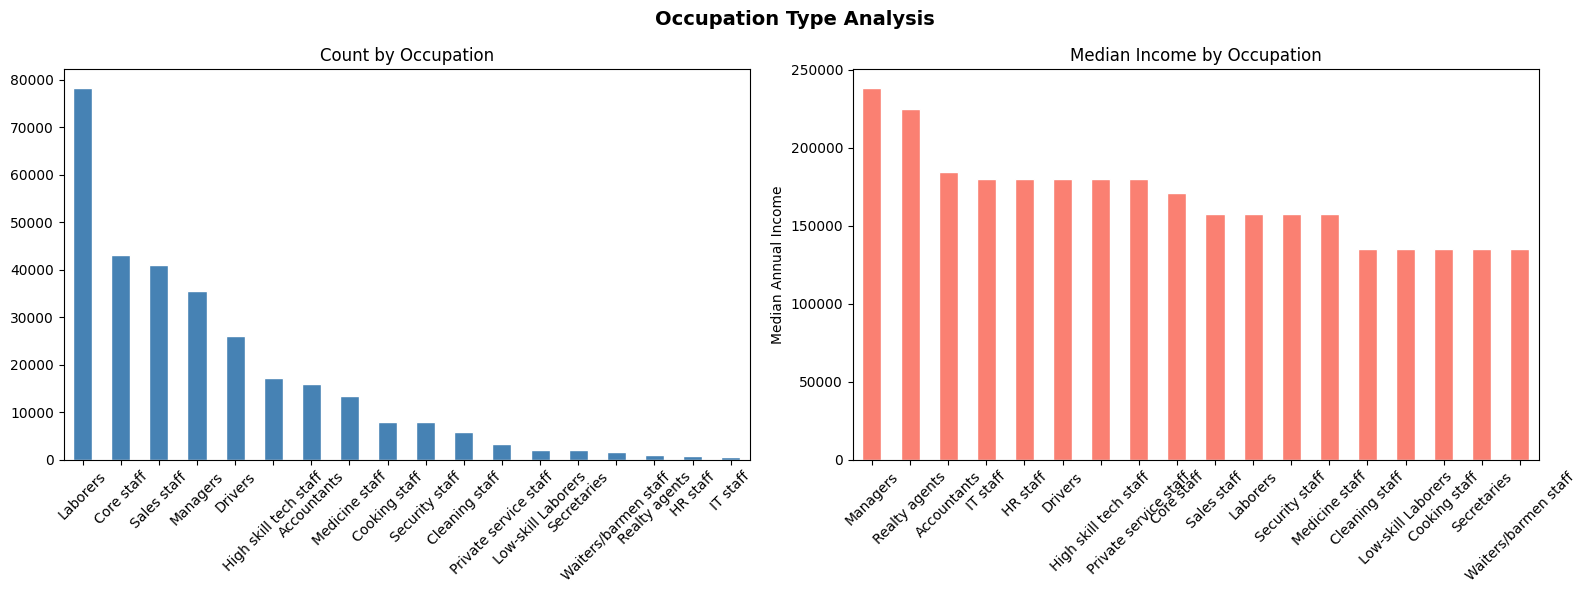

In [64]:
# Occupation type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Occupation Type Analysis", fontsize=14, fontweight='bold')

# Count by occupation
app['OCCUPATION_TYPE'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Count by Occupation")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# Mean income by occupation
app.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].median().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title("Median Income by Occupation")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Annual Income")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [65]:
# Are nulls in OCCUPATION_TYPE related to unemployed (DAYS_EMPLOYED = 365243)?
unemployed = app[app['DAYS_EMPLOYED'] == 365243]
print(f"Unemployed with null occupation: {unemployed['OCCUPATION_TYPE'].isnull().sum()}")
print(f"Total unemployed: {len(unemployed)}")
print(f"\nOccupation distribution among unemployed:")
print(unemployed['OCCUPATION_TYPE'].value_counts(dropna=False))

Unemployed with null occupation: 75329
Total unemployed: 75329

Occupation distribution among unemployed:
OCCUPATION_TYPE
NaN    75329
Name: count, dtype: int64


In [66]:
# FLAG_MOBIL variance check
print("FLAG_MOBIL value counts:")
print(app['FLAG_MOBIL'].value_counts())
print(f"\nUnique values: {app['FLAG_MOBIL'].unique()}")

FLAG_MOBIL value counts:
FLAG_MOBIL
1    438557
Name: count, dtype: int64

Unique values: [1]


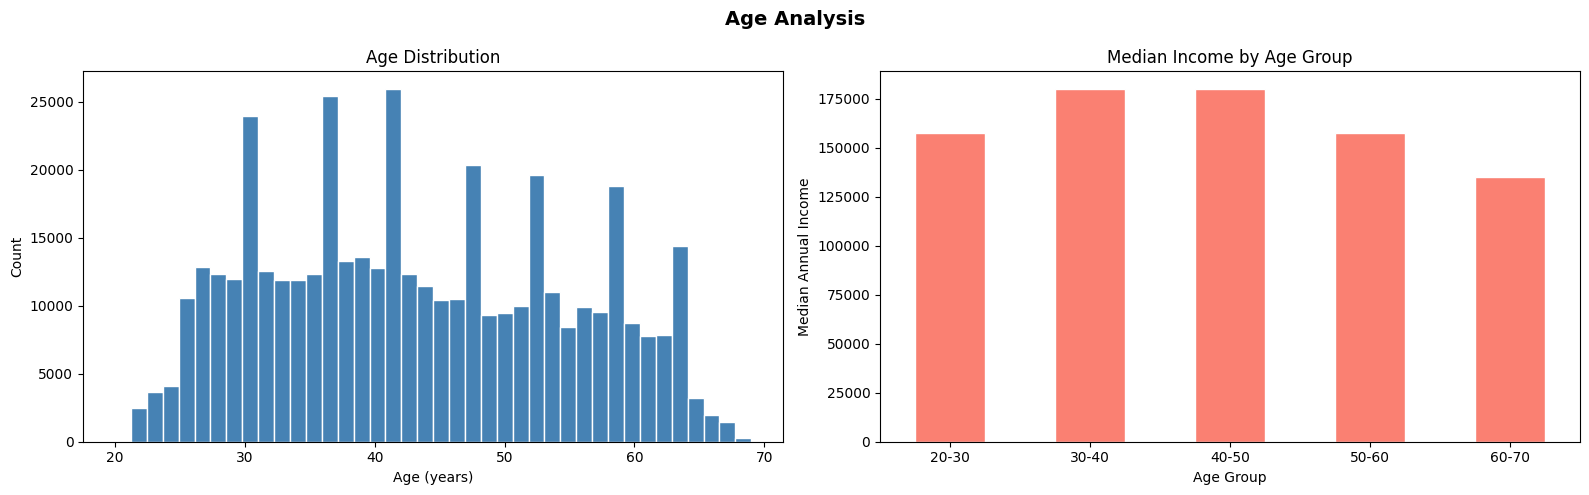

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Age Analysis", fontsize=14, fontweight='bold')

# Age distribution
axes[0].hist(app['AGE'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")

# Median income by age group
app['AGE_GROUP'] = pd.cut(app['AGE'], bins=[20, 30, 40, 50, 60, 70], 
                           labels=['20-30', '30-40', '40-50', '50-60', '60-70'])
app.groupby('AGE_GROUP', observed=True)['AMT_INCOME_TOTAL'].median().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title("Median Income by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Median Annual Income")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [68]:
# NOTE: DAYS_EMPLOYED = 365243 is a placeholder for unemployed customers (75,329 cases, 17.18%)
# Will be treated separately - create binary flag IS_UNEMPLOYED and impute/handle separately

# OCCUPATION_TYPE has 134,203 nulls (30.6%):
# - 75,329 explained by DAYS_EMPLOYED = 365243 (unemployed/pensioners)
# - 58,874 unexplained nulls → will be imputed as 'Unknown' in preprocessing

# FLAG_MOBIL has zero variance - all values are 1 (everyone has a mobile phone)
# Will be dropped in preprocessing - provides no predictive value

# Age shows expected income pattern (lower at extremes, stable in middle)
# However, income variation across age groups is moderate
# NAME_INCOME_TYPE and OCCUPATION_TYPE likely stronger predictors

# CREDIT RECORD

In [69]:
credit = pd.read_csv("credit_record.csv")

In [70]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [71]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [72]:
credit.columns.to_list()

['ID', 'MONTHS_BALANCE', 'STATUS']

In [73]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [74]:
credit['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [75]:
# Status dictionary
status_dict = {
    '0': 'No overdue (on time)',
    '1': '1-29 days overdue',
    '2': '30-59 days overdue',
    '3': '60-89 days overdue',
    '4': '90-119 days overdue',
    '5': '120+ days overdue',
    'C': 'Paid off / closed',
    'X': 'No loan this month'
}

print("=== STATUS Dictionary ===")
for k, v in status_dict.items():
    count = credit[credit['STATUS'] == k].shape[0]
    pct = count / len(credit) * 100
    print(f"  {k} → {v:<25} | {count:>7,} ({pct:.2f}%)")

=== STATUS Dictionary ===
  0 → No overdue (on time)      | 383,120 (36.54%)
  1 → 1-29 days overdue         |  11,090 (1.06%)
  2 → 30-59 days overdue        |     868 (0.08%)
  3 → 60-89 days overdue        |     320 (0.03%)
  4 → 90-119 days overdue       |     223 (0.02%)
  5 → 120+ days overdue         |   1,693 (0.16%)
  C → Paid off / closed         | 442,031 (42.16%)
  X → No loan this month        | 209,230 (19.95%)


In [76]:
# Bad client = anyone who ever had STATUS 2, 3, 4 or 5 (30+ days overdue)
# Good client = only 0, C, X

# KEY FINDINGS

In [77]:
# ============================================================
# EDA KEY FINDINGS & PREPROCESSING NOTES
# ============================================================

# APPLICATION RECORD
# ------------------
# 1. FLAG_MOBIL → zero variance (all = 1), drop in preprocessing
# 2. DAYS_EMPLOYED = 365243 → placeholder for unemployed (75,329 cases, 17.18%)
#    → create binary flag IS_UNEMPLOYED, handle separately
# 3. OCCUPATION_TYPE → 134,203 nulls (30.6%):
#    - 75,329 explained by unemployment
#    - 58,874 unexplained → impute as 'Unknown'
# 4. AMT_INCOME_TOTAL → heavy right skew, 430 extreme outliers (>1M)
#    → consider log transformation or capping at p99
# 5. Students (NAME_INCOME_TYPE) → only 17 cases, statistically irrelevant
#    → merge with another category or drop
# 6. Gender imbalance → 2x more women (294k vs 144k)
#    → men earn ~23% more (median 184k vs 157k)
# 7. DAYS_BIRTH / DAYS_EMPLOYED → convert to AGE and YEARS_EMPLOYED
# 8. CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY → binary encode (Y/N → 1/0)

# CREDIT RECORD
# -------------
# 9.  Dataset extremely imbalanced → only 1.35% bad clients (STATUS 2-5)
#     → SMOTE will be essential in modeling
# 10. STATUS 5 (120+ days) > STATUS 2+3+4 combined
#     → clients who fall into serious default tend to stay there
# 11. Target definition → BAD = any STATUS in [2, 3, 4, 5]
#     → GOOD = STATUS in [0, C, X]